# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [3]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
print("Libraries loaded ✓")


Libraries loaded ✓


## Task 2 — Load & Inspect Data

In [4]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')

print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [5]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()
print("null values:\n",df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB
null values:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [6]:
# TODO: Print df.describe() to view summary statistics
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** _398 rows, 9 columns______________

**Q2.** Which column contains missing values and how many?  
**Answer:** horesepower, contains 6 missing values_______________


## Task 3 — Pre-Processing

In [7]:
# TODO: Check and print missing values per column
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nNaN rows = {df.isnull().any(axis=1).sum()} "
      f"({df.isnull().any(axis=1).mean()*100:.2f}% of data)")
# Then drop all rows that contain NaN values (they are < 2% of data)
df.dropna(inplace=True)
print("Data frame after dropping null values: ", df.shape)


Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

NaN rows = 6 (1.51% of data)
Data frame after dropping null values:  (392, 9)


In [8]:
# TODO: Check for and remove duplicate rows
print("Number of duplicate rows: ", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Number of duplicate rows:  0


In [9]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
# 3. Strip & lowercase 'car_name'
df['cylinders']=df['cylinders'].astype('category')
df['model_year']=df['model_year'].astype('category')

df['origin']=df['origin'].map({1:'usa', 2:'europe', 3:'japan'})

df['car_name']=df['car_name'].str.strip().str.lower()

print(df.dtypes)

mpg              float64
cylinders       category
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model_year      category
origin            object
car_name          object
dtype: object


In [10]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']   # fill in
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']   # fill in


## Task 4 — Feature Engineering

In [11]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'

df['mpg_level']=pd.cut(df['mpg'],
                          bins=[0, 17, 29, df['mpg'].max()+1],
                          labels=['low','medium','high'],
                          right=False)

In [12]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company']=df['car_name'].str.split().str[0]

print(df[['mpg', 'mpg_level', 'car_company', 'car_name']].head(8))

    mpg mpg_level car_company                   car_name
0  18.0    medium   chevrolet  chevrolet chevelle malibu
1  15.0       low       buick          buick skylark 320
2  18.0    medium    plymouth         plymouth satellite
3  16.0       low         amc              amc rebel sst
4  17.0    medium        ford                ford torino
5  15.0       low        ford           ford galaxie 500
6  14.0       low   chevrolet           chevrolet impala
7  14.0       low    plymouth          plymouth fury iii


## Task 5 — Categorical EDA

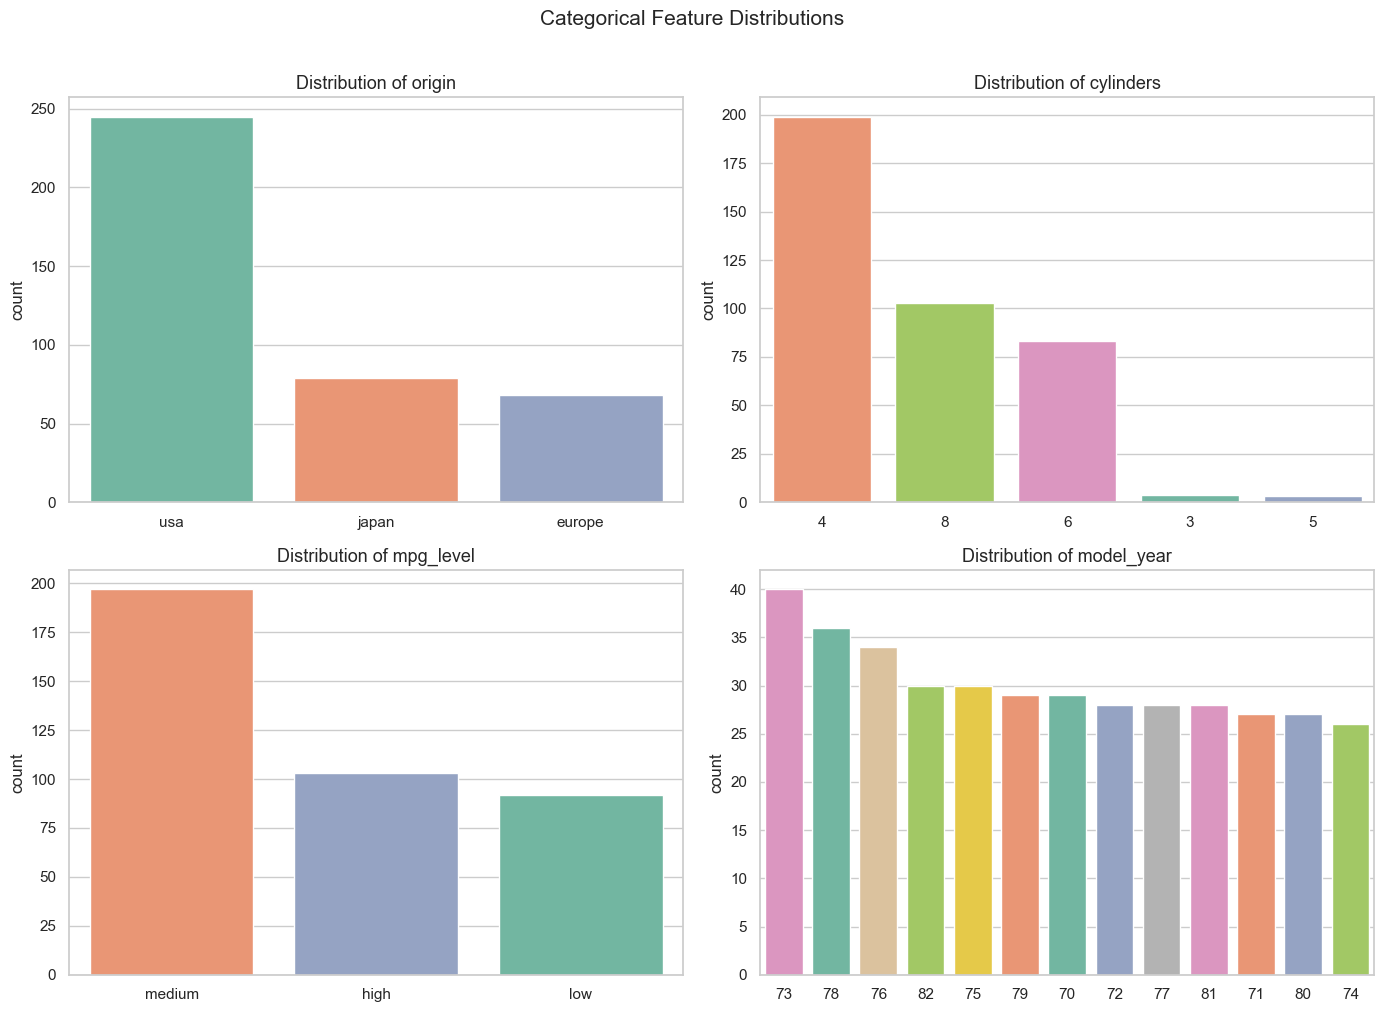

In [14]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_plot_cols = ['origin','cylinders','mpg_level','model_year']

for ax, col in zip(axes.flat, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(
        data=df,
        x=col,
        order=order,
        ax=ax,
        hue=col,
        palette='Set2',
        legend=False
    )
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel('')

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin', 'cylinders', 'mpg_level']:
    counts=df[col].value_counts(normalize=True)
    dominant_class=counts.index[0]
    proportion=counts.iloc[0]*100
    print(f"{col}: dominant class = '{dominant_class}' → {proportion:.1f}%")

origin: dominant class = 'usa' → 62.5%
cylinders: dominant class = '4' → 50.8%
mpg_level: dominant class = 'medium' → 50.3%


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


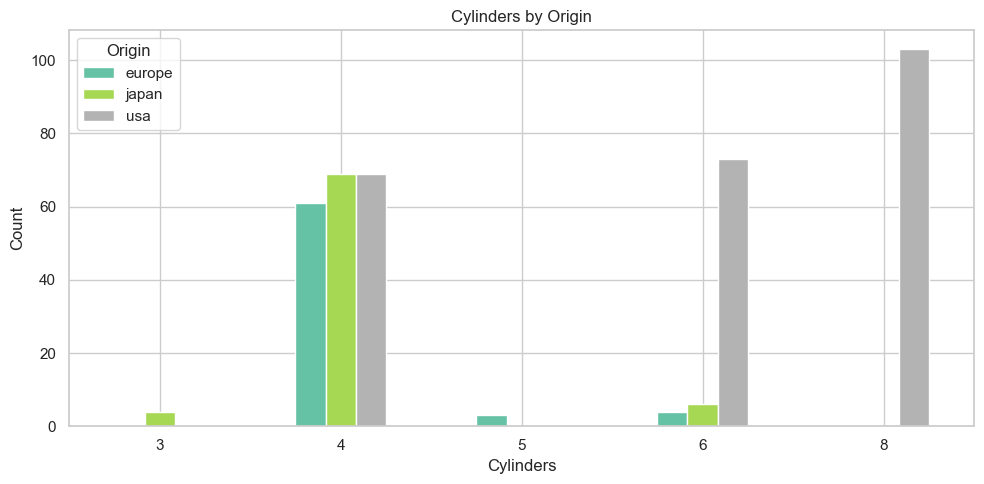

In [16]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
ct = pd.crosstab(df['cylinders'], df['origin'])
print(ct)

ct.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Cylinders by Origin')
plt.xlabel('Cylinders'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.legend(title='Origin')
plt.tight_layout(); plt.show()


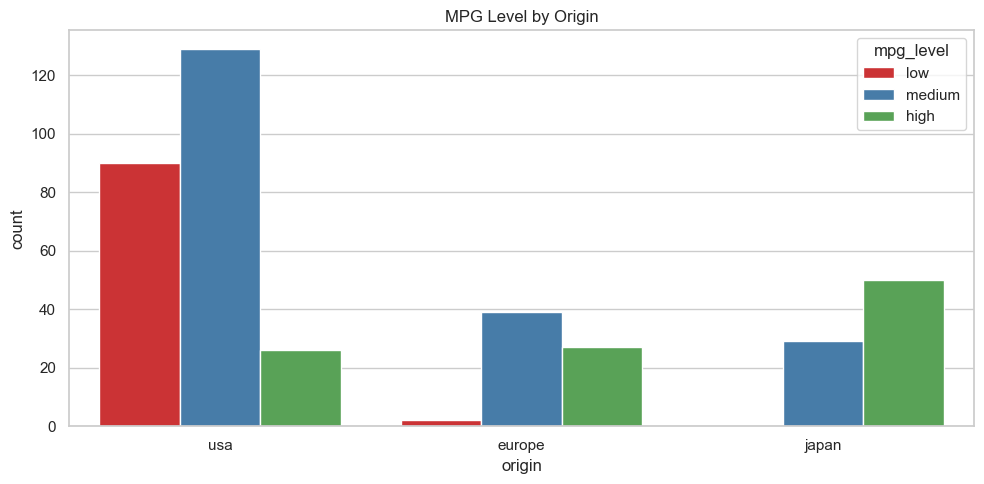

In [17]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')
# ── mpg_level × origin ───────────────────────────────────────────────────
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='origin', hue='mpg_level',
              order=['usa','europe','japan'],
              hue_order=['low','medium','high'], palette='Set1')
plt.title('MPG Level by Origin')
plt.tight_layout(); plt.show()



**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** japan_______________

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 4, it represents 50.8%_______________


## Task 6 — Numerical EDA

In [ ]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)



In [ ]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
    # TODO: implement
    pass



In [ ]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)



In [ ]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level



**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** _______________

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** _______________


## Task 7 — Numerical vs Categorical

In [ ]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)



In [ ]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'



In [ ]:
# TODO: Plot a line chart showing mean mpg per model_year



**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** _______________

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** _______________


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | | |
| horsepower | | |
| weight | | |
| acceleration | | |
| cylinders | | |
| origin | | |
| model_year | | |
